In [7]:
import json
import os

import pandas as pd

# Plot the accuracy

# WITHOUT BEAM MATCHING
dir = '../data/results/experiments/beam_matching_experiment'
errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])

# WITH BEAM MATCHING
dir = '../data/results/experiments/beam_matching_experiment_1'
control_errors_df = pd.read_csv(os.path.join(dir, 'errors.csv')).drop(columns=['Unnamed: 0'])

with open(os.path.join(dir, 'config.json')) as f:
    config = json.load(f)

print(config)

errors_df

{'wknn_k': 2, 'rf_param': 'sinr', 'cluster_rf_param': 'sinr', 'operator_choice': [10], 'cluster_range': [0], 'n_runs': 50, 'campaigns': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20], 'use_beam_matching': False, 'runtime': 172.15760254859924}


,0
0,11.854862
1,11.668001
2,11.948519
3,11.972669
4,11.844745
5,10.966038
6,11.408532
7,11.893303
8,12.380467
9,11.928410


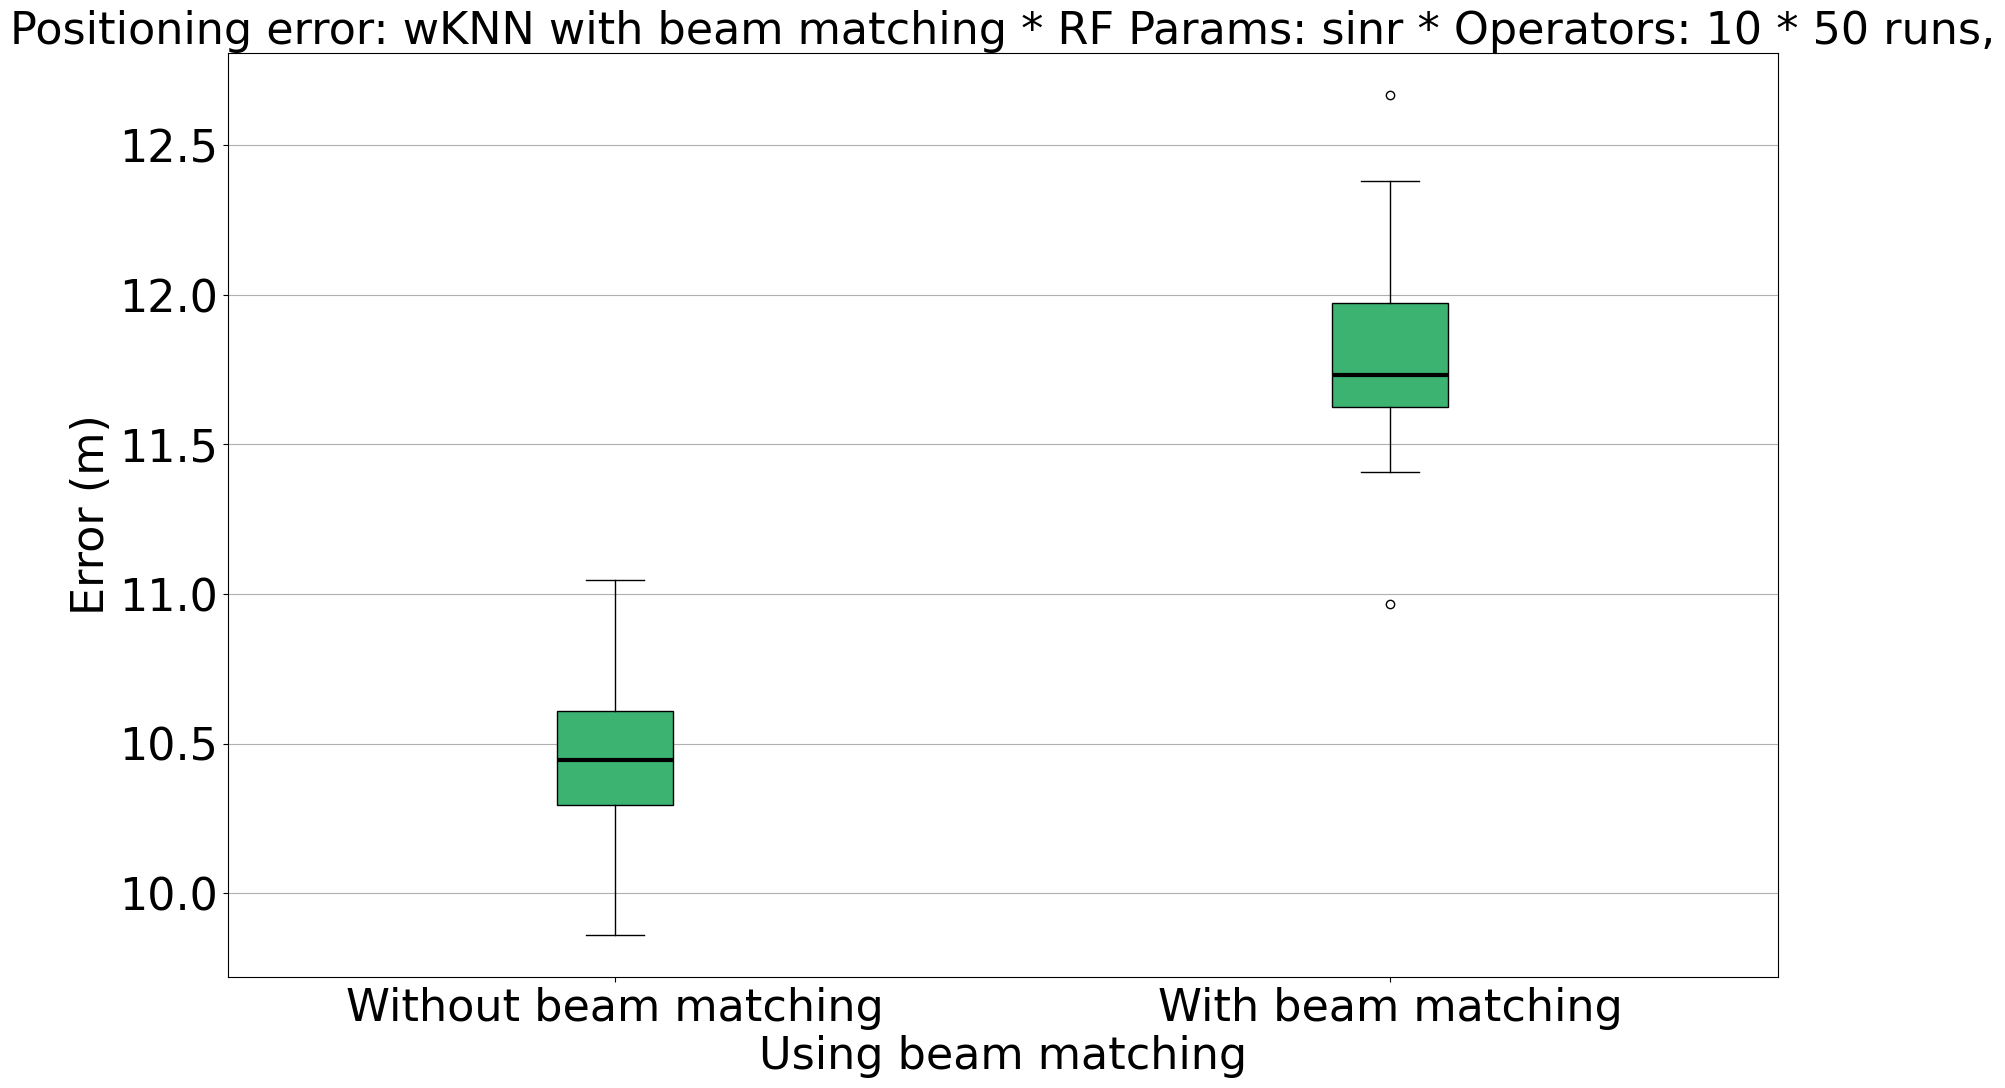

,Without beam matching,With beam matching
0,10.480455,11.854862
1,10.455803,11.668001
2,10.536000,11.948519
3,10.040094,11.972669
4,10.735591,11.844745
5,10.188897,10.966038
6,10.093731,11.408532
7,10.869052,11.893303
8,10.791205,12.380467
9,10.337636,11.928410


In [8]:

from scripts.plotting import make_boxplot
from scripts.utils import operators_to_str

param_str = f'RF Params: {config["rf_param"]}'
operator_str = f'Operators: {operators_to_str(config["operator_choice"])}'

title_string = f'wKNN with beam matching * {param_str} * {operator_str} * {config["n_runs"]} runs,'

control_errors_df.rename(columns={'0': 'Without beam matching'}, inplace=True)
errors_df.rename(columns={'0': 'With beam matching'}, inplace=True)

df = pd.concat([control_errors_df, errors_df], axis=1)

make_boxplot(
    df=df,
    title=f'Positioning error: {title_string}',
    x_label='Using beam matching',
    y_label='Error (m)',
    color='mediumseagreen',

)

df
